In [1]:
print("CUstomer Churn Project")

CUstomer Churn Project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn

In [3]:
df=pd.read_csv(r'C:\Users\rehan\OneDrive\Desktop\Data Science\6-Months-Data-Science\Customer_churn_project\data\Telco-Customer-Churn.csv')

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df['customerID'].unique()

<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

In [6]:
df.drop('customerID',axis=1,inplace=True)

In [7]:
print("duplicate values : ",df.duplicated().sum())
print("Null values : ",df.isnull().sum())

duplicate values :  22
Null values :  gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [10]:
df['gender']=df['gender'].str.strip().str.title().map({'Female':0,'Male':1})

In [11]:
df['Partner'].unique()


<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [12]:
df['Partner']=df['Partner'].str.strip().str.title().map({'No':0,'Yes':1})


In [13]:
df['Dependents'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [14]:
df['Dependents']=df['Dependents'].str.strip().str.title().map({'No':0,'Yes':1})

In [15]:
df['PhoneService'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [16]:
df['PhoneService']=df['PhoneService'].str.strip().str.title().map({'No':0,'Yes':1})


In [17]:
df['MultipleLines'].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [18]:
df['MultipleLines'] = df['MultipleLines'].str.strip().str.title().map({
    'No Phone Service': 0,
    'No': 1,
    'Yes': 2
})

In [19]:
df['InternetService'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [20]:
df['InternetService']=df['InternetService'].str.strip().str.title().map({
    'Dsl':1,
    'Fiber Optic':2,
    'No':0
})

In [21]:
df['OnlineSecurity'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [22]:
df['OnlineSecurity']=df['OnlineSecurity'].str.strip().str.title().map({'No':0,'No Internet Service':1,'Yes':2})

In [23]:
df['OnlineBackup'].unique()

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [24]:
df['OnlineBackup']=df['OnlineBackup'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [25]:
df['DeviceProtection'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [26]:
df['DeviceProtection']=df['DeviceProtection'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [27]:
df['TechSupport'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [28]:
df['TechSupport']=df['TechSupport'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [29]:
df['StreamingTV'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [30]:
df['StreamingTV']=df['StreamingTV'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [31]:
df['StreamingMovies'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [32]:
df['StreamingMovies']=df['StreamingMovies'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [33]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [34]:
df['Contract'] = df['Contract'].str.strip().str.title().map({
    'Month-To-Month': 0,
    'One Year': 1,
    'Two Year': 2
})

In [35]:
df['PaperlessBilling'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [36]:
df['PaperlessBilling'] = df['PaperlessBilling'].str.strip().map({
    'No': 0,
    'Yes': 1
})

In [37]:
df['PaymentMethod'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [38]:
df['PaymentMethod'] = df['PaymentMethod'].str.strip().map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})

In [39]:
df['Churn'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [40]:
df['Churn']=df['Churn'].str.strip().map({'No':0,'Yes':1})

In [41]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,1,0,2,1,1,1,1,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,1,56.95,1889.5,0
2,1,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,1,2,0,1,1,1,1,1,0,1,0,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,1,2,1,2,2,2,2,1,1,1,84.80,1990.5,0
7039,0,0,1,1,72,1,2,2,0,2,2,1,2,2,1,1,3,103.20,7362.9,0
7040,0,0,1,1,11,0,0,1,2,1,1,1,1,1,0,1,0,29.60,346.45,0
7041,1,1,1,0,4,1,2,2,0,1,1,1,1,1,0,1,1,74.40,306.6,1


In [42]:
x=df.drop('Churn',axis=1)

In [43]:
y=df[['Churn']]

In [44]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,0,1,0,2,1,1,1,1,0,1,0,29.85,29.85
1,1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,1,56.95,1889.5
2,1,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,1,53.85,108.15
3,1,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,2,42.30,1840.75
4,0,0,0,0,2,1,1,2,0,1,1,1,1,1,0,1,0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,1,2,1,2,2,2,2,1,1,1,84.80,1990.5
7039,0,0,1,1,72,1,2,2,0,2,2,1,2,2,1,1,3,103.20,7362.9
7040,0,0,1,1,11,0,0,1,2,1,1,1,1,1,0,1,0,29.60,346.45
7041,1,1,1,0,4,1,2,2,0,1,1,1,1,1,0,1,1,74.40,306.6


In [45]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [46]:
df.shape

(7021, 20)

In [47]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,1,0,2,1,1,1,1,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,1,56.95,1889.5,0
2,1,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,1,2,0,1,1,1,1,1,0,1,0,70.70,151.65,1


In [48]:
df.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,1,0,1,1,24,1,2,1,2,1,2,2,2,2,1,1,1,84.80,1990.5,0
7039,0,0,1,1,72,1,2,2,0,2,2,1,2,2,1,1,3,103.20,7362.9,0
7040,0,0,1,1,11,0,0,1,2,1,1,1,1,1,0,1,0,29.60,346.45,0
7041,1,1,1,0,4,1,2,2,0,1,1,1,1,1,0,1,1,74.40,306.6,1
7042,1,0,0,0,66,1,1,2,2,1,2,2,2,2,2,1,2,105.65,6844.5,0


In [49]:
df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   int64  
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   int64  
 3   Dependents        7021 non-null   int64  
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   int64  
 6   MultipleLines     7021 non-null   int64  
 7   InternetService   7021 non-null   int64  
 8   OnlineSecurity    7021 non-null   int64  
 9   OnlineBackup      7021 non-null   int64  
 10  DeviceProtection  7021 non-null   int64  
 11  TechSupport       7021 non-null   int64  
 12  StreamingTV       7021 non-null   int64  
 13  StreamingMovies   7021 non-null   int64  
 14  Contract          7021 non-null   int64  
 15  PaperlessBilling  7021 non-null   int64  
 16  PaymentMethod     7021 non-null   int64  
 17  MonthlyChar

In [50]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [51]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [52]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [53]:
df.info()

<class 'pandas.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   int64  
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   int64  
 3   Dependents        7010 non-null   int64  
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   int64  
 6   MultipleLines     7010 non-null   int64  
 7   InternetService   7010 non-null   int64  
 8   OnlineSecurity    7010 non-null   int64  
 9   OnlineBackup      7010 non-null   int64  
 10  DeviceProtection  7010 non-null   int64  
 11  TechSupport       7010 non-null   int64  
 12  StreamingTV       7010 non-null   int64  
 13  StreamingMovies   7010 non-null   int64  
 14  Contract          7010 non-null   int64  
 15  PaperlessBilling  7010 non-null   int64  
 16  PaymentMethod     7010 non-null   int64  
 17  MonthlyChar

In [54]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.504280,0.162767,0.484023,0.299429,32.520399,0.902996,1.326248,1.225963,0.789729,1.131098,1.130100,1.076177,1.170756,1.174750,0.690728,0.593153,1.317404,64.888666,2290.353388,0.264907
std,0.500017,0.369180,0.499780,0.458041,24.520441,0.295985,0.643333,0.777600,0.860846,0.737334,0.736833,0.707190,0.755878,0.757606,0.833345,0.491281,1.150581,30.064769,2266.820832,0.441315
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,35.750000,408.312500,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,70.400000,1403.875000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,56.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.900000,3807.837500,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000


In [55]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

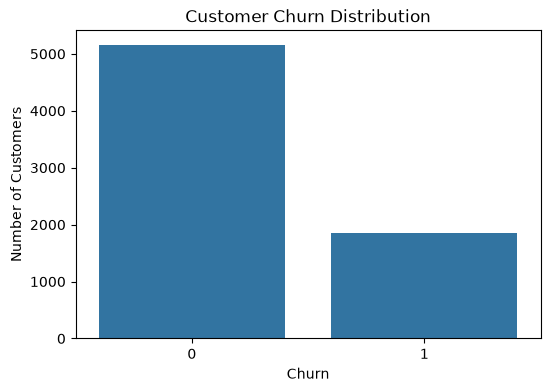

In [56]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

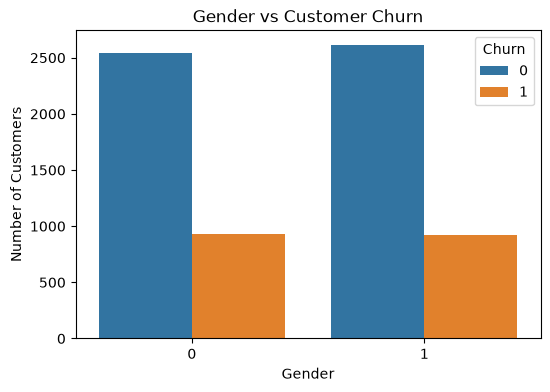

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

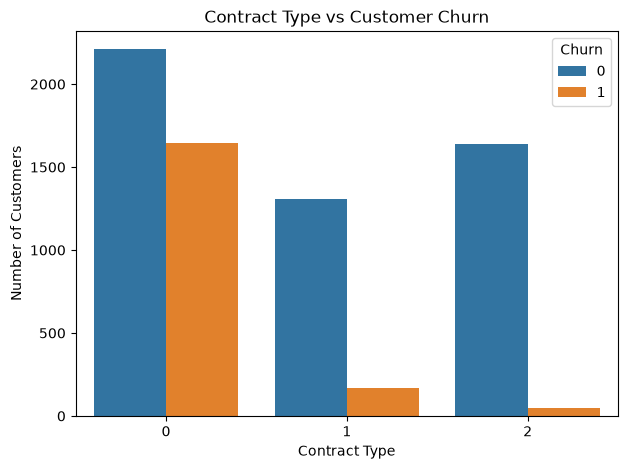

In [58]:
plt.figure(figsize=(7,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

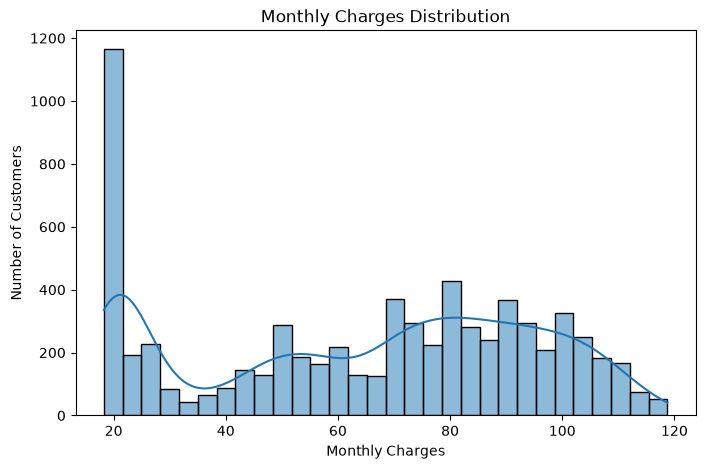

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

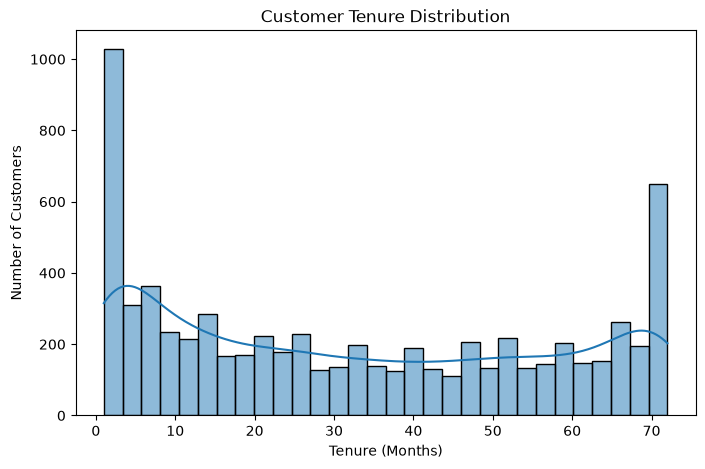

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

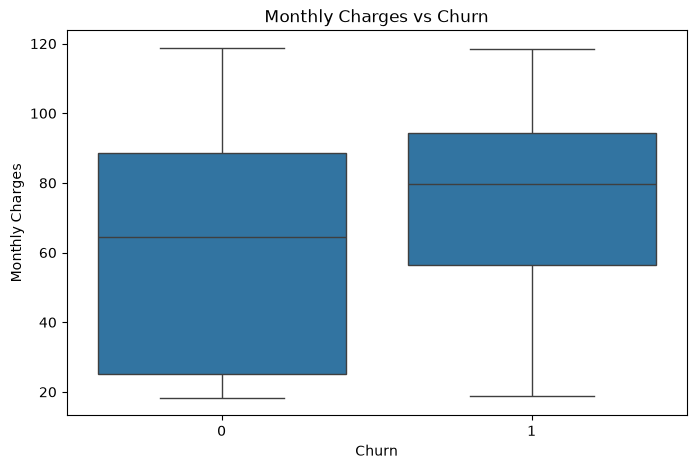

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

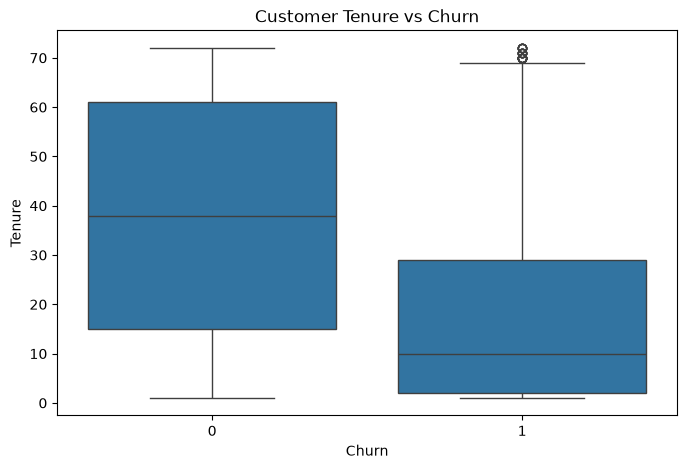

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

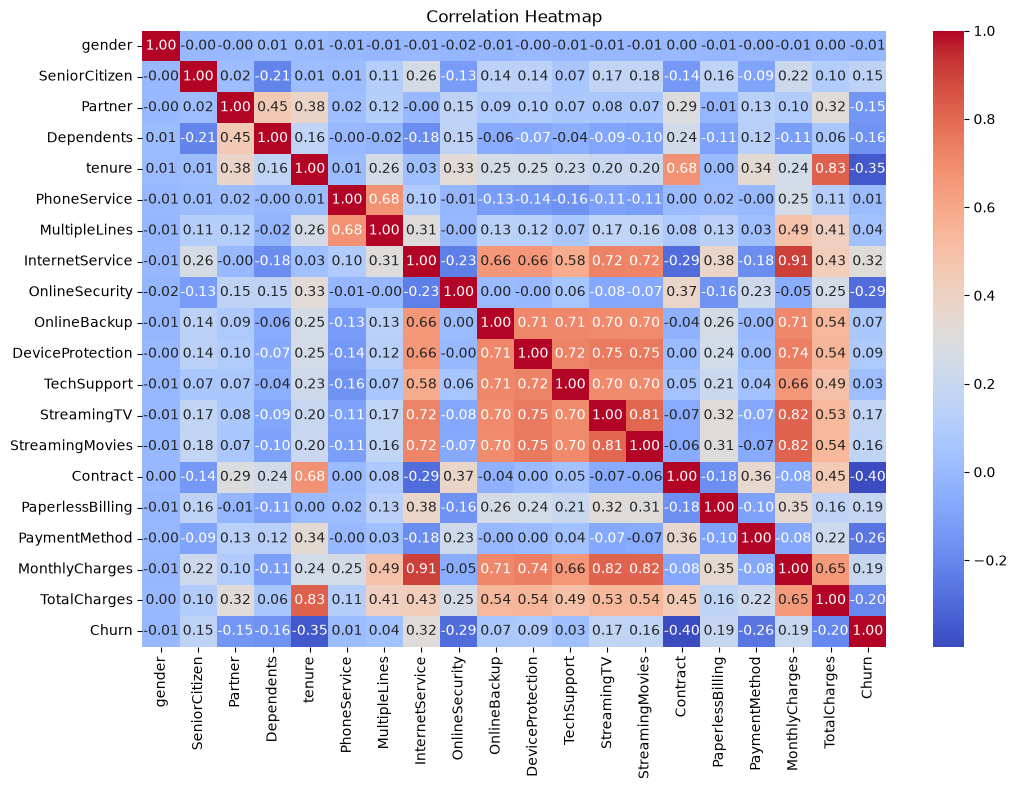

In [63]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

#### Final Insights from the Data

In [64]:
corr = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

print(corr)

Churn               1.000000
InternetService     0.316967
MonthlyCharges      0.194008
PaperlessBilling    0.190518
StreamingTV         0.165909
StreamingMovies     0.164072
SeniorCitizen       0.151270
DeviceProtection    0.085297
OnlineBackup        0.074780
MultipleLines       0.037266
TechSupport         0.027219
PhoneService        0.011072
gender             -0.008694
Partner            -0.148670
Dependents         -0.162366
TotalCharges       -0.198362
PaymentMethod      -0.261992
OnlineSecurity     -0.288246
tenure             -0.353339
Contract           -0.395968
Name: Churn, dtype: float64


In [65]:
df.isnull().sum().sort_values(ascending=False)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [66]:
#df.to_csv("cleaned_Customer_churn_data", index=False)

C:\Users\rehan\AppData\Local\Temp\ipykernel_880\158810975.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No', 'Yes'])


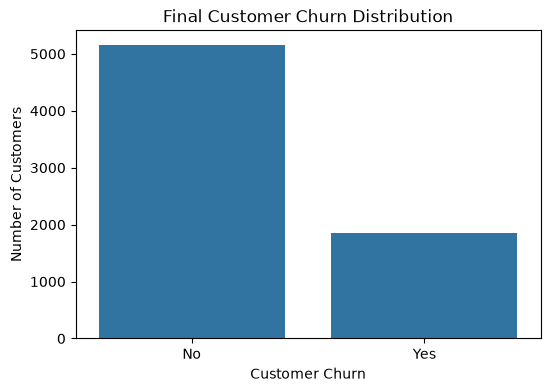

In [67]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Churn', data=df)

ax.set_xticklabels(['No', 'Yes'])

plt.title("Final Customer Churn Distribution")
plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

plt.show()

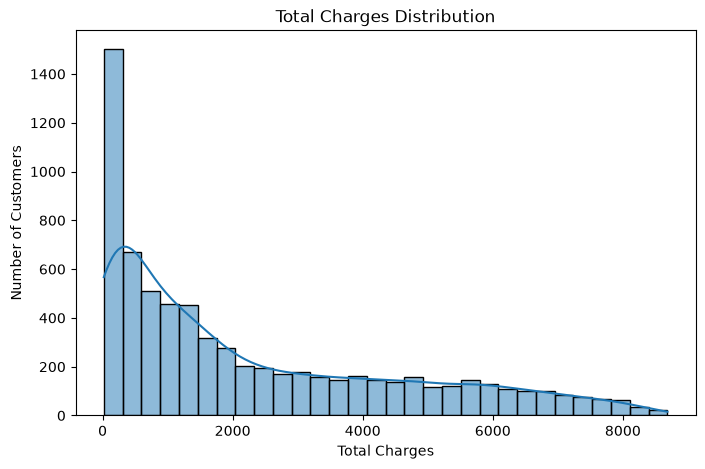

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalCharges'], bins=30, kde=True)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

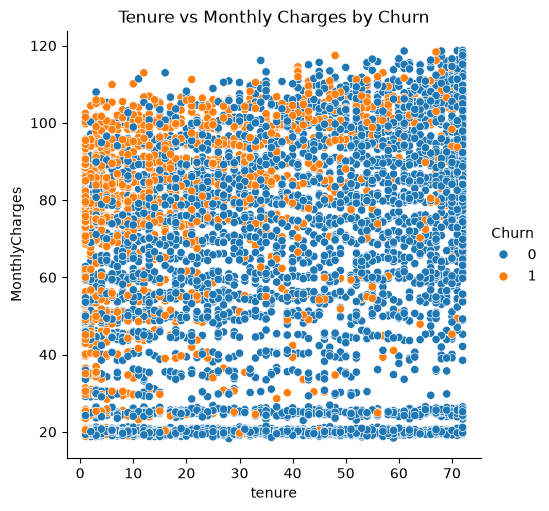

In [69]:
sns.relplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn'
)

plt.title("Tenure vs Monthly Charges by Churn")

plt.show()

#### sklern

In [70]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop('Churn', axis=1)

# Target
y = df['Churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5608, 19)
X_test : (1402, 19)
y_train: (5608,)
y_test : (1402,)


In [74]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
356,0,1,0,0,16,1,2,1,2,1,1,1,1,1,0,1,0,54.10,889.00
211,0,0,0,0,1,0,0,1,0,1,1,1,1,1,0,0,0,25.25,25.25
2594,0,0,1,0,65,1,2,2,0,2,2,2,2,2,2,1,2,107.65,7082.85
4641,0,0,0,0,1,0,0,1,0,1,1,1,1,1,0,0,1,24.40,24.40
2521,1,1,1,0,36,1,2,2,0,1,1,1,1,2,0,1,3,85.25,3132.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4315,0,0,0,0,1,1,1,2,0,1,1,1,2,1,0,0,0,79.55,79.55
2044,1,0,0,0,7,1,1,0,1,0,0,0,0,0,1,0,1,19.50,128.60
3873,0,0,1,1,51,0,0,1,2,1,1,2,1,1,2,0,2,34.20,1782.00
6159,0,0,0,1,2,1,1,0,1,0,0,0,0,0,1,0,2,20.50,38.25


In [75]:
y_train

356     0
211     0
2594    0
4641    0
2521    1
       ..
4315    1
2044    0
3873    0
6159    0
1771    1
Name: Churn, Length: 5608, dtype: int64

In [78]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
744,0,0,0,0,5,1,1,1,0,1,1,1,1,1,0,1,3,44.05,202.15
669,0,0,1,0,70,0,0,1,0,2,2,2,2,2,2,0,2,57.80,4039.30
5764,1,1,0,0,57,1,2,2,2,1,1,2,1,2,2,0,0,93.75,5625.55
5469,1,0,0,0,33,1,1,2,0,2,2,1,1,1,0,1,3,79.00,2576.80
2030,1,0,0,1,2,1,2,1,2,2,1,1,1,1,0,0,2,60.95,134.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,1,0,0,0,25,1,1,2,2,1,2,2,2,2,0,1,0,105.50,2686.05
5831,0,0,0,0,9,1,1,2,0,1,1,1,2,2,0,1,2,90.80,809.75
2597,1,0,1,0,71,1,2,2,2,2,2,1,2,2,1,1,0,109.60,7854.15
1343,1,0,1,1,64,1,1,1,2,1,2,1,2,2,1,1,3,73.05,4688.65


In [79]:
y_test

744     0
669     0
5764    0
5469    0
2030    0
       ..
14      0
5831    1
2597    0
1343    0
3415    1
Name: Churn, Length: 1402, dtype: int64

In [80]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [81]:
pred = lr.predict(X_test)

In [82]:
pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1402,))

In [83]:
y_test

744     0
669     0
5764    0
5469    0
2030    0
       ..
14      0
5831    1
2597    0
1343    0
3415    1
Name: Churn, Length: 1402, dtype: int64

In [84]:
from sklearn.metrics import accuracy_score

pred = lr.predict(X_test)

print("Test Accuracy :", accuracy_score(y_test, pred) * 100)
print("Train Accuracy:", lr.score(X_train, y_train) * 100)

Test Accuracy : 80.81312410841655
Train Accuracy: 80.59914407988587


#### SVM

In [85]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score

print("Test Accuracy :", accuracy_score(y_test, pred_svm) * 100)
print("Train Accuracy:", svm.score(X_train, y_train) * 100)

Test Accuracy : 73.53780313837375
Train Accuracy: 73.5021398002853
